In [1]:
#importing the all libaries needed 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1. LOAD DATA 
df = pd.read_csv("StudentsPerformance.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# 2. FEATURE ENGINEERING 
df["average_score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
) / 3

# Excellent Student

df["excellent_student"] = (
    df["average_score"] >= 80
).astype(int)

print("\nClass Distribution:")
print(df["excellent_student"].value_counts())



Class Distribution:
excellent_student
0    802
1    198
Name: count, dtype: int64


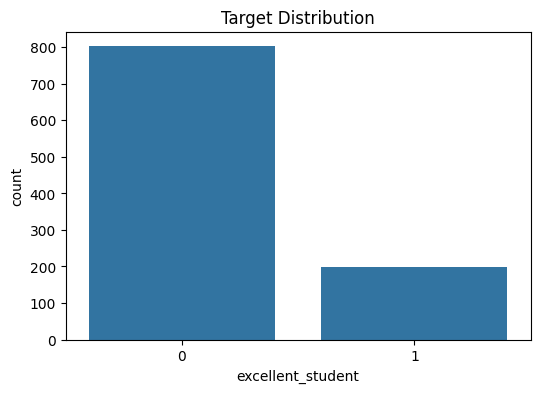

In [4]:
# 3. EDA 
plt.figure(figsize=(6,4))

sns.countplot(
    x="excellent_student",
    data=df
)

plt.title("Target Distribution")
plt.savefig("target_distribution.png")
plt.show()

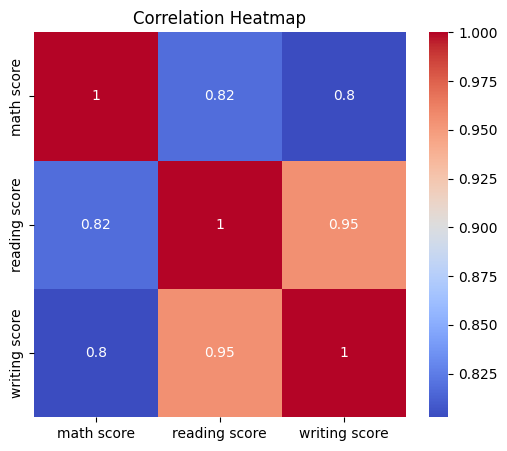

In [5]:
# Correlation Heatmap 
plt.figure(figsize=(6,5))

sns.heatmap(
    df[
        [
            "math score",
            "reading score",
            "writing score"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()


In [6]:
# 4. FEATURES / TARGET 

X = df.drop(
    columns=[
        "excellent_student",
        "average_score"
    ]
)

y = df["excellent_student"]


In [7]:
# 5. TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [8]:
# 6. PREPROCESSING 
categorical_cols = X.select_dtypes(
    include="object"
).columns

numeric_cols = X.select_dtypes(
    exclude="object"
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)


In [9]:
# 7. MODELS 
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        eval_metric="logloss",
        random_state=42
    )
}

results = []

fitted_models = {}


In [10]:
# 8. TRAIN + EVALUATE
for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_prob = pipe.predict_proba(
        X_test
    )[:,1]

    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred
    )

    rec = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "CV Accuracy":
        cv_scores.mean(),

        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    })

    fitted_models[name] = pipe

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       160
           1       1.00      0.93      0.96        40

    accuracy                           0.98       200
   macro avg       0.99      0.96      0.98       200
weighted avg       0.99      0.98      0.98       200



XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       160
           1       1.00      0.95      0.97        40

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99   

In [11]:
# 9. RESULTS TABLE
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\n")
print(results_df)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)



                 Model  CV Accuracy  Accuracy  Precision  Recall        F1  \
0  Logistic Regression      0.99875     1.000        1.0   1.000  1.000000   
2              XGBoost      0.98375     0.990        1.0   0.950  0.974359   
1        Random Forest      0.98625     0.985        1.0   0.925  0.961039   

    ROC-AUC  
0  1.000000  
2  0.999922  
1  0.998203  


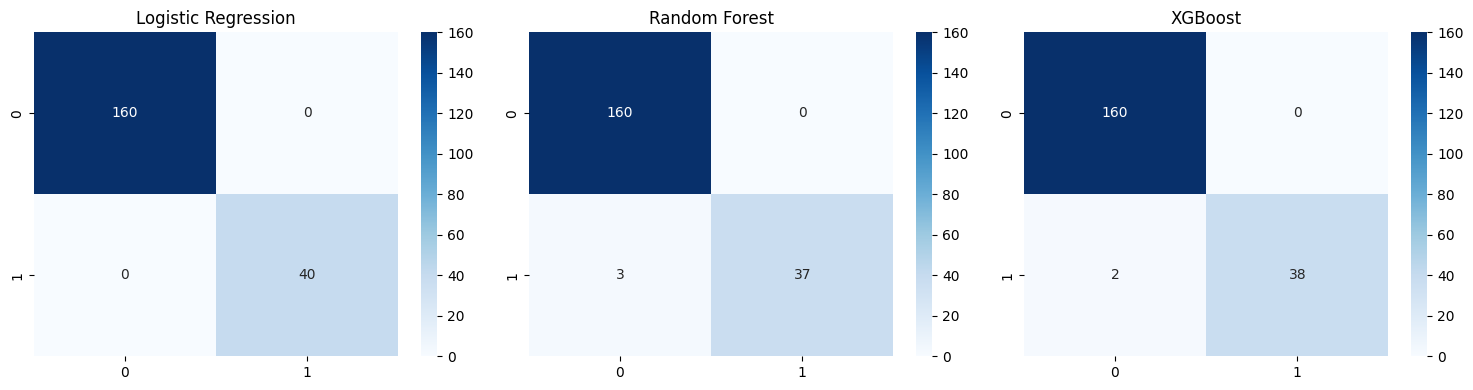

In [13]:
# 10. CONFUSION MATRICES
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for ax, (name, pipe) in zip(
    axes,
    fitted_models.items()
):

    pred = pipe.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)

plt.tight_layout()
plt.savefig(
    "confusion_matrices.png"
)
plt.show()


<Figure size 800x600 with 0 Axes>

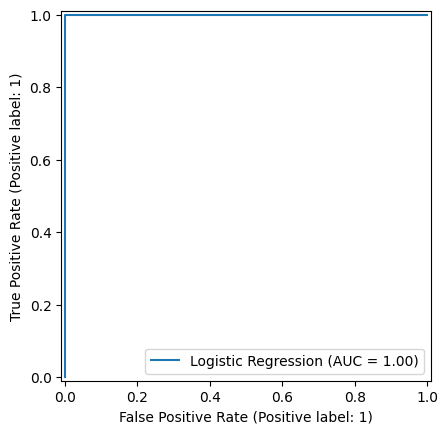

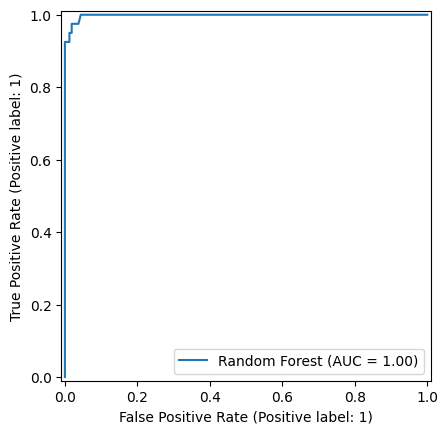

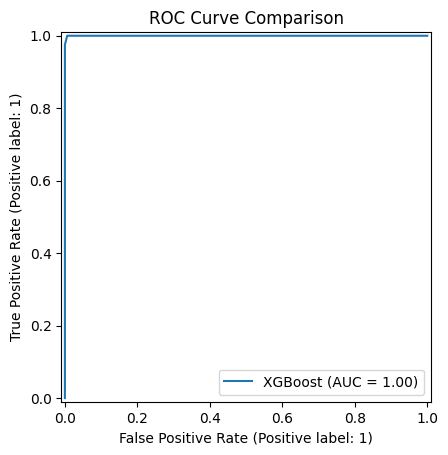

In [14]:
# 11. ROC CURVES 
plt.figure(figsize=(8,6))

for name, pipe in fitted_models.items():

    probs = pipe.predict_proba(
        X_test
    )[:,1]

    RocCurveDisplay.from_predictions(
        y_test,
        probs,
        name=name
    )

plt.title("ROC Curve Comparison")

plt.savefig(
    "roc_curves.png"
)

plt.show()


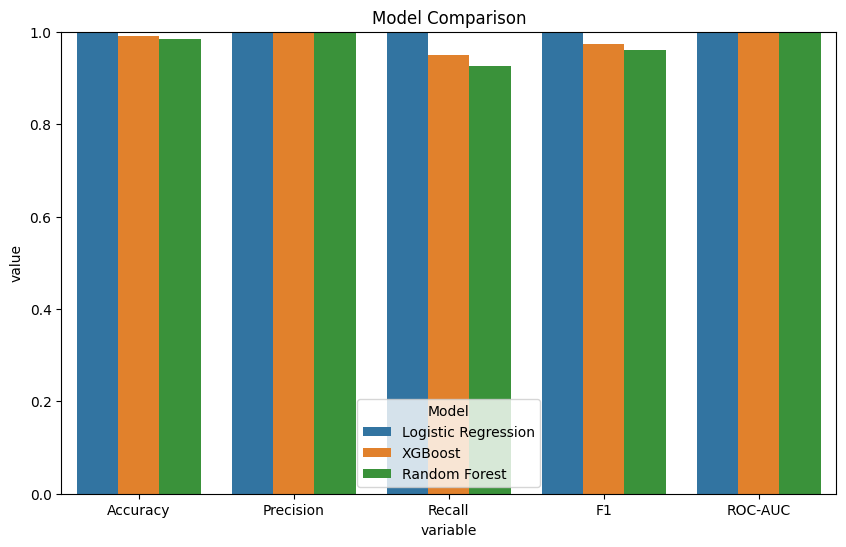

In [15]:
# 12. METRIC COMPARISON 
metric_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=metric_df,
    x="variable",
    y="value",
    hue="Model"
)

plt.ylim(0,1)

plt.title(
    "Model Comparison"
)

plt.savefig(
    "metric_comparison.png"
)

plt.show()


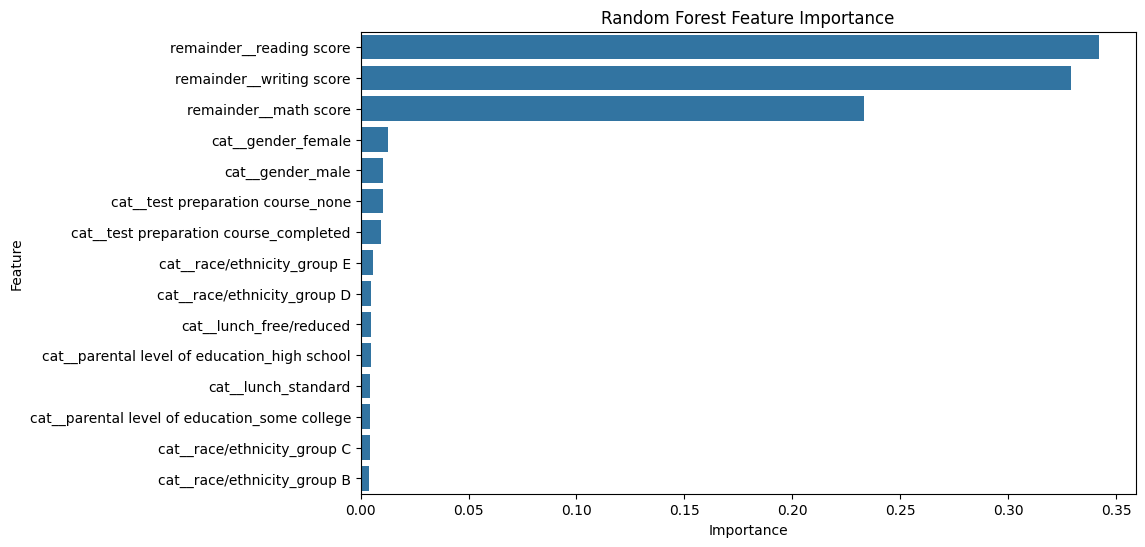

In [16]:
# 13. FEATURE IMPORTANCE 
rf = fitted_models[
    "Random Forest"
]

feature_names = rf.named_steps[
    "preprocessor"
].get_feature_names_out()

rf_importance = rf.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": rf_importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.savefig(
    "feature_importance.png"
)

plt.show()


In [17]:
# 14. SAVEING THE  BEST MODEL
best_model = fitted_models[
    results_df.iloc[0]["Model"]
]

import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

print("\nBest Model Saved Successfully!")


Best Model Saved Successfully!
